In [2]:
import pandas as pd

df = pd.read_csv("bank-additional-full.csv", sep=';')
df.head()
df.shape

(41188, 21)

In [3]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,...,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,...,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


In [4]:
df['y'].value_counts(normalize=True)

no     0.887346
yes    0.112654
Name: y, dtype: float64

In [5]:
df.select_dtypes(include='object').columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [7]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [9]:
df['y'].value_counts(normalize=True)

0    0.887346
1    0.112654
Name: y, dtype: float64

In [10]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace('.', '_', regex=False)
    .str.replace(' ', '_', regex=False)
    .str.replace('-', '_', regex=False)
)


In [11]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

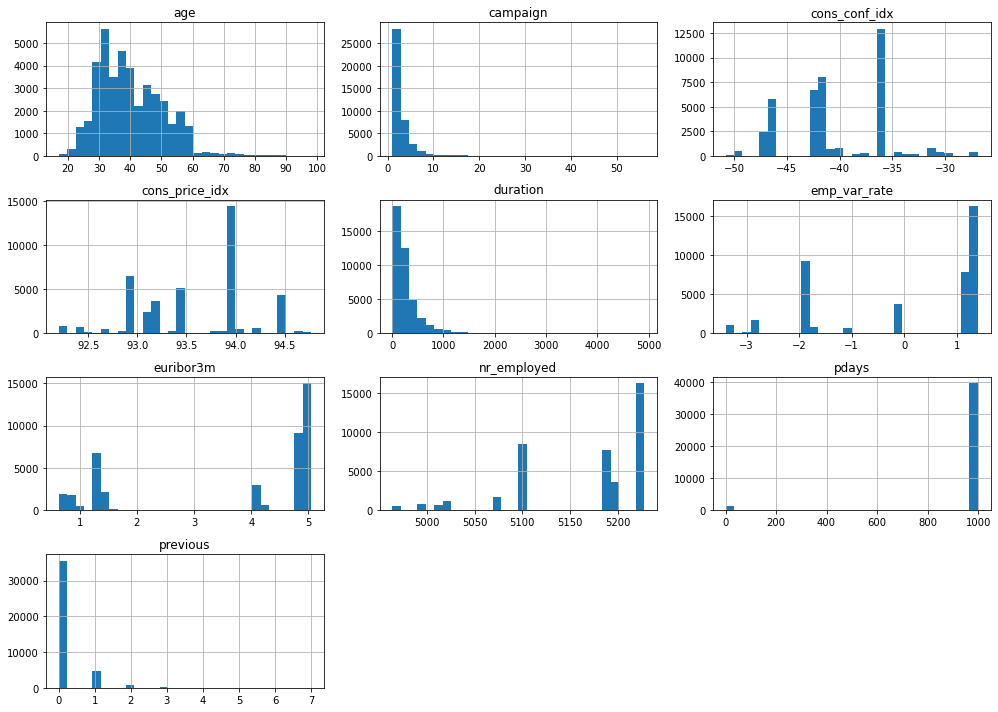

In [12]:
import matplotlib.pyplot as plt

num_cols = [
    'age','duration','campaign','pdays','previous',
    'emp_var_rate','cons_price_idx','cons_conf_idx',
    'euribor3m','nr_employed'
]

df[num_cols].hist(bins=30, figsize=(14,10))
plt.tight_layout()
plt.show()


In [13]:
df.groupby('job')['y'].mean()
df.groupby('education')['y'].mean()
df.groupby('month')['y'].mean()

month
apr    0.204787
aug    0.106021
dec    0.489011
jul    0.090466
jun    0.105115
mar    0.505495
may    0.064347
nov    0.101439
oct    0.438719
sep    0.449123
Name: y, dtype: float64

In [14]:
df.groupby('job')['y'].mean()

job
admin.           0.129726
blue-collar      0.068943
entrepreneur     0.085165
housemaid        0.100000
management       0.112175
retired          0.252326
self-employed    0.104856
services         0.081381
student          0.314286
technician       0.108260
unemployed       0.142012
unknown          0.112121
Name: y, dtype: float64

In [15]:
df.groupby('education')['y'].mean()

education
basic.4y               0.102490
basic.6y               0.082024
basic.9y               0.078246
high.school            0.108355
illiterate             0.222222
professional.course    0.113485
university.degree      0.137245
unknown                0.145003
Name: y, dtype: float64

In [16]:
df.groupby('contact')['y'].mean()

contact
cellular     0.147376
telephone    0.052313
Name: y, dtype: float64

In [17]:
df.groupby('poutcome')['y'].mean().sort_values()

poutcome
nonexistent    0.088322
failure        0.142286
success        0.651129
Name: y, dtype: float64

In [18]:
df.groupby('marital')['y'].mean().sort_values()

marital
married     0.101573
divorced    0.103209
single      0.140041
unknown     0.150000
Name: y, dtype: float64

In [19]:
df.groupby('housing')['y'].mean().sort_values()

housing
unknown    0.108081
no         0.108796
yes        0.116194
Name: y, dtype: float64

In [20]:
df.groupby('loan')['y'].mean().sort_values()

loan
unknown    0.108081
yes        0.109315
no         0.113402
Name: y, dtype: float64

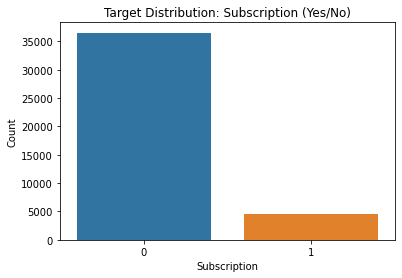

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Target Distribution: Subscription (Yes/No)")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()


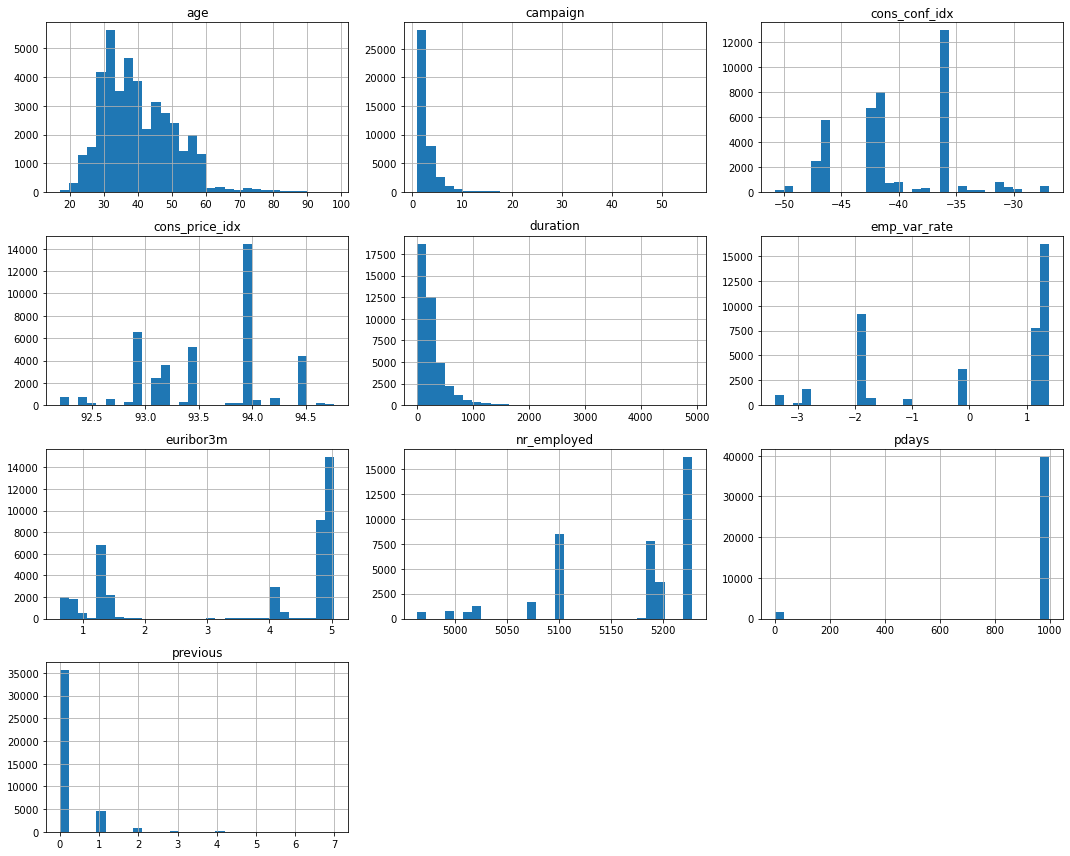

In [22]:
num_cols = [
    'age','duration','campaign','pdays','previous',
    'emp_var_rate','cons_price_idx','cons_conf_idx',
    'euribor3m','nr_employed'
]

df[num_cols].hist(bins=30, figsize=(15,12))
plt.tight_layout()
plt.show()


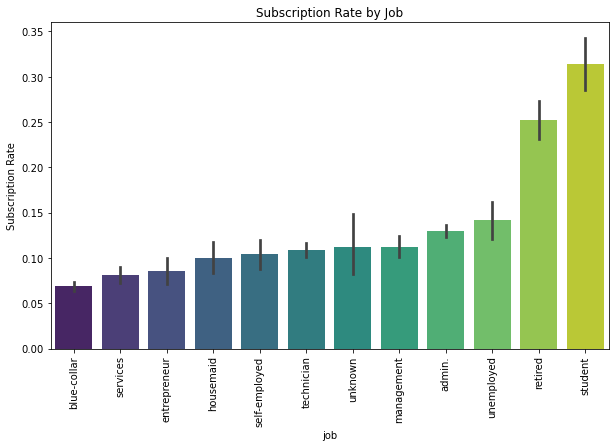

In [23]:
job_order = df.groupby('job')['y'].mean().sort_values().index

plt.figure(figsize=(10,6))
sns.barplot(x='job', y='y', data=df, order=job_order, palette='viridis')
plt.xticks(rotation=90)
plt.title("Subscription Rate by Job")
plt.ylabel("Subscription Rate")
plt.show()


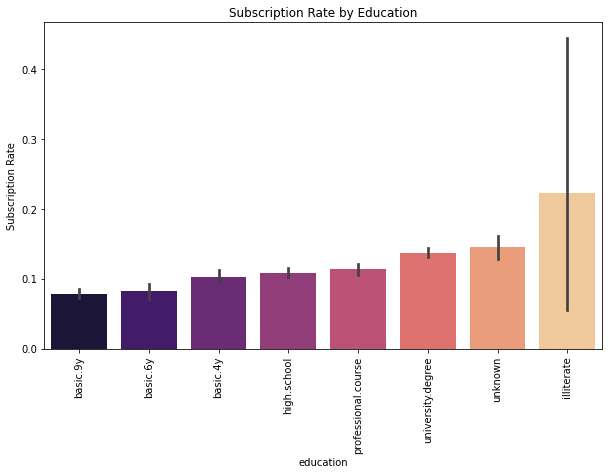

In [24]:
edu_order = df.groupby('education')['y'].mean().sort_values().index

plt.figure(figsize=(10,6))
sns.barplot(x='education', y='y', data=df, order=edu_order, palette='magma')
plt.xticks(rotation=90)
plt.title("Subscription Rate by Education")
plt.ylabel("Subscription Rate")
plt.show()


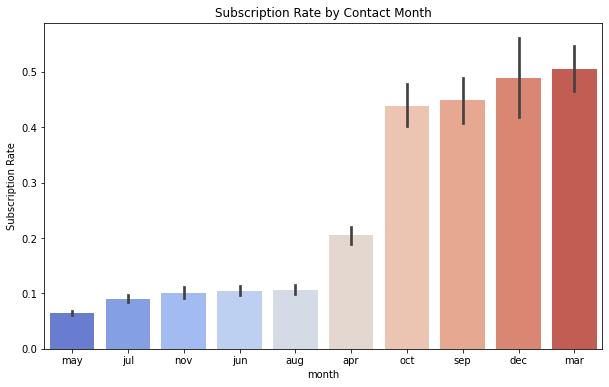

In [25]:
month_order = df.groupby('month')['y'].mean().sort_values().index

plt.figure(figsize=(10,6))
sns.barplot(x='month', y='y', data=df, order=month_order, palette='coolwarm')
plt.title("Subscription Rate by Contact Month")
plt.ylabel("Subscription Rate")
plt.show()


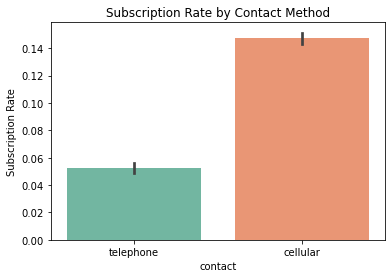

In [26]:
contact_order = df.groupby('contact')['y'].mean().sort_values().index

plt.figure(figsize=(6,4))
sns.barplot(x='contact', y='y', data=df, order=contact_order, palette='Set2')
plt.title("Subscription Rate by Contact Method")
plt.ylabel("Subscription Rate")
plt.show()


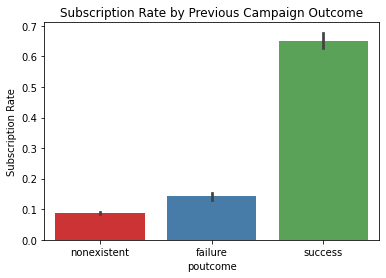

In [27]:
poutcome_order = df.groupby('poutcome')['y'].mean().sort_values().index

plt.figure(figsize=(6,4))
sns.barplot(x='poutcome', y='y', data=df, order=poutcome_order, palette='Set1')
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.ylabel("Subscription Rate")
plt.show()


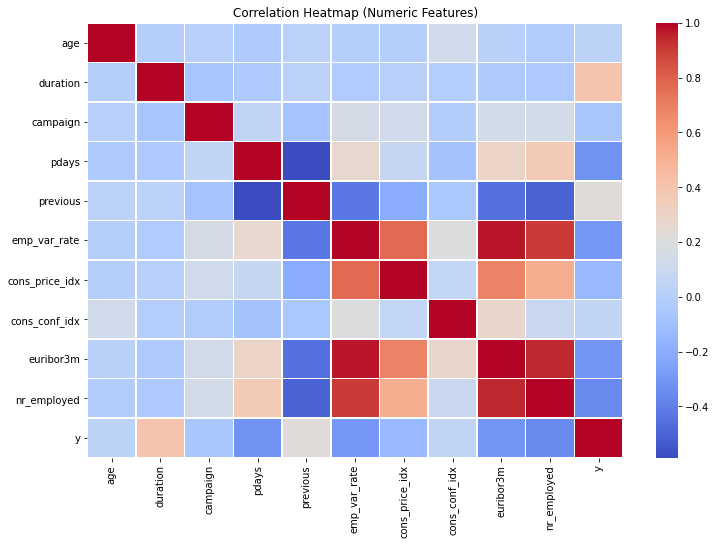

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols + ['y']].corr(), annot=False, cmap='coolwarm', linewidths=.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


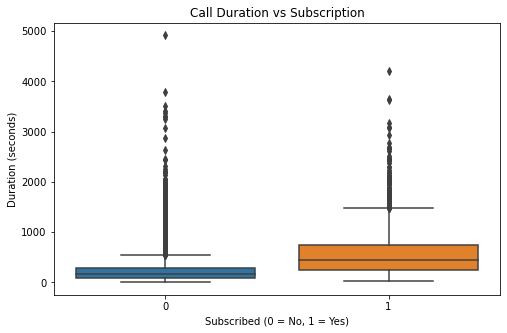

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='duration', data=df)
plt.title("Call Duration vs Subscription")
plt.xlabel("Subscribed (0 = No, 1 = Yes)")
plt.ylabel("Duration (seconds)")
plt.show()


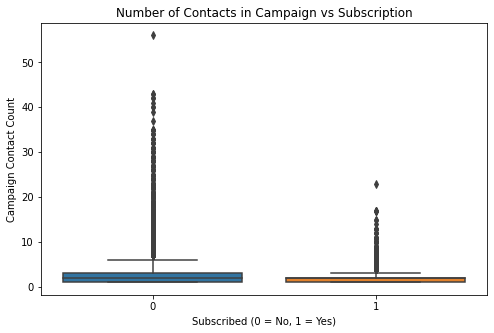

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='campaign', data=df)
plt.title("Number of Contacts in Campaign vs Subscription")
plt.xlabel("Subscribed (0 = No, 1 = Yes)")
plt.ylabel("Campaign Contact Count")
plt.show()


/Users/deepali/opt/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:369: UserWarning: Default bandwidth for data is 0; skipping density estimation.
  warnings.warn(msg, UserWarning)
/Users/deepali/opt/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:369: UserWarning: Default bandwidth for data is 0; skipping density estimation.
  warnings.warn(msg, UserWarning)


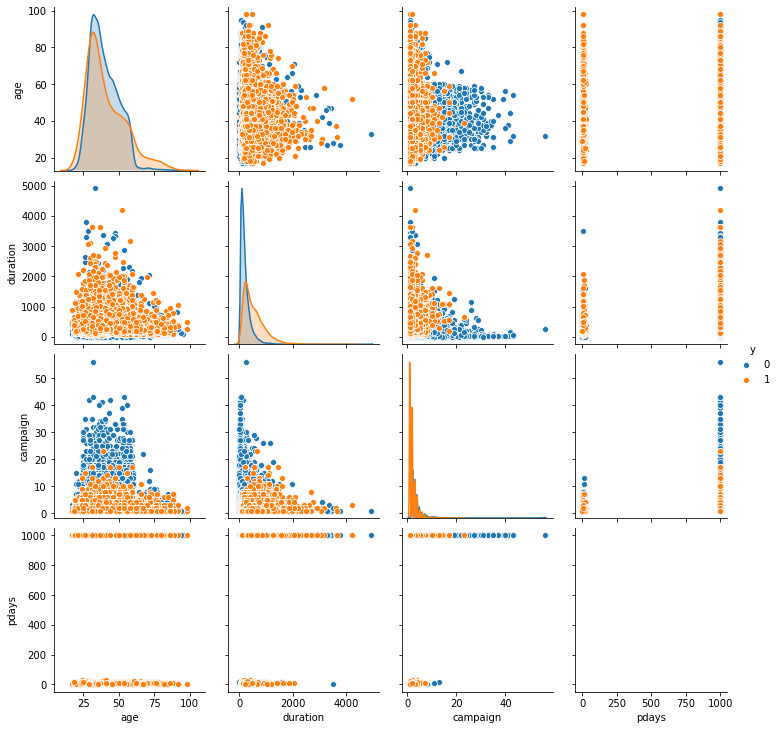

In [32]:
sns.pairplot(df[['age','duration','campaign','pdays','y']], hue='y')
plt.show()

In [34]:
df['y'] = df['y'].astype('category')


In [37]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [38]:
import pandas as pd
import numpy as np


df = pd.read_csv("bank-additional-full.csv", sep=';')


numeric_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


obj_cols = df.select_dtypes(include=['object']).columns

for col in obj_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("Unique jobs:", df['job'].unique())  # quick check for 'housemaid' etc.


num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


df['y'] = df['y'].map({'yes': 1, 'no': 0})

Unique jobs: ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']


In [40]:

obj_cols = df.select_dtypes(include=['object']).columns
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

numeric_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


df['y'] = df['y'].map({'yes': 1, 'no': 0})

for col in ['default', 'housing', 'loan']:
    df[col] = df[col].map({'yes': 1, 'no': 0, 'unknown': 0})


cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = [c for c in cat_cols if c != 'y']  
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("After encoding, dtypes:")
print(df.dtypes.head())
print("\nShape after encoding:", df.shape)


After encoding, dtypes:
age         int64
default     int64
housing     int64
loan        int64
duration    int64
dtype: object

Shape after encoding: (41188, 51)


In [42]:
import numpy as np


print("NaNs in X_train before cleaning:", X_train.isna().sum().sum())
print("NaNs in X_test before cleaning:", X_test.isna().sum().sum())

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

print("NaNs in X_train after cleaning:", X_train.isna().sum().sum())
print("NaNs in X_test after cleaning:", X_test.isna().sum().sum())


NaNs in X_train before cleaning: 0
NaNs in X_test before cleaning: 0
NaNs in X_train after cleaning: 0
NaNs in X_test after cleaning: 0


In [55]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report
)

df = pd.read_csv("bank-additional-full.csv", sep=';')

print("Original shape:", df.shape)
print("Original dtypes:\n", df.dtypes, "\n")


obj_cols = df.select_dtypes(include=['object']).columns

for col in obj_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()


numeric_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


df['y'] = df['y'].map({'yes': 1, 'no': 0})

for col in ['default', 'housing', 'loan']:
    df[col] = df[col].map({'yes': 1, 'no': 0, 'unknown': 0})


num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print("Dtypes before dummy encoding:\n", df.dtypes, "\n")


cat_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Shape after get_dummies:", df.shape)
print("Remaining object columns:", df.select_dtypes(include=['object']).columns.tolist(), "\n")

assert df.select_dtypes(include=['object']).empty, "Still contains non-numeric columns!"


X = df.drop('y', axis=1)
y = df['y']

print("Final X shape:", X.shape)
print("y value counts:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)

log_reg.fit(X_train_scaled, y_train)

y_pred  = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression Performance ===")
print("Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1-score: ", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_proba), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred)[:600])

Original shape: (41188, 21)
Original dtypes:
 age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object 

Dtypes before dummy encoding:
 age                 int64
job                object
marital            object
education          object
default             int64
housing             int64
loan                int64
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int

In [56]:
import pandas as pd
import numpy as np

coef_series = pd.Series(log_reg.coef_[0], index=X.columns)

print("\n Top 15 features pushing toward SUBSCRIBING (y=1):")
print(coef_series.sort_values(ascending=False).head(15))

print("\n Top 15 features pushing toward NOT subscribing (y=0):")
print(coef_series.sort_values().head(15))



 Top 15 features pushing toward SUBSCRIBING (y=1):
duration                       1.821947
euribor3m                      1.460426
cons.price.idx                 1.190876
month_aug                      0.393128
month_mar                      0.224460
poutcome_success               0.167511
poutcome_nonexistent           0.124095
education_university.degree    0.122594
job_retired                    0.105251
marital_single                 0.063492
day_of_week_wed                0.055366
education_unknown              0.043176
job_student                    0.042330
month_sep                      0.037018
month_oct                      0.029799
dtype: float64

 Top 15 features pushing toward NOT subscribing (y=0):
emp.var.rate         -3.405262
month_may            -0.395215
month_jun            -0.276565
pdays                -0.210980
month_nov            -0.193612
contact_telephone    -0.192116
job_blue-collar      -0.121712
nr.employed          -0.093485
default              -0.08790

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)   # no scaling for trees

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== RANDOM FOREST Performance ===")
print("Accuracy: ", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:   ", round(recall_score(y_test, y_pred_rf), 4))
print("F1-score: ", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_proba_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Feature importance
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)
print("\nTop 15 Random Forest features:")
print(rf_importances.sort_values(ascending=False).head(15))



=== RANDOM FOREST Performance ===
Accuracy:  0.912
Precision: 0.6727
Recall:    0.4253
F1-score:  0.5211
ROC-AUC:   0.9464

Confusion Matrix:
[[10677   288]
 [  800   592]]

Top 15 Random Forest features:
duration             0.392017
euribor3m            0.097497
nr.employed          0.071414
age                  0.059568
emp.var.rate         0.045449
campaign             0.030715
cons.conf.idx        0.028990
cons.price.idx       0.023760
pdays                0.017966
poutcome_success     0.016784
housing              0.012619
contact_telephone    0.012114
month_may            0.011662
previous             0.011506
marital_married      0.008987
dtype: float64


In [58]:
!pip install xgboost

In [60]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
import pandas as pd


gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,      # depth of individual trees
    subsample=0.8,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb  = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print("\n=== GRADIENT BOOSTING Performance ===")
print("Accuracy: ", round(accuracy_score(y_test, y_pred_gb), 4))
print("Precision:", round(precision_score(y_test, y_pred_gb), 4))
print("Recall:   ", round(recall_score(y_test, y_pred_gb), 4))
print("F1-score: ", round(f1_score(y_test, y_pred_gb), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_proba_gb), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

# Feature importance
gb_importances = pd.Series(gb.feature_importances_, index=X.columns)
print("\nTop 15 Gradient Boosting features:")
print(gb_importances.sort_values(ascending=False).head(15))




=== GRADIENT BOOSTING Performance ===
Accuracy:  0.9186
Precision: 0.672
Recall:    0.5417
F1-score:  0.5998
ROC-AUC:   0.9486

Confusion Matrix:
[[10597   368]
 [  638   754]]

Top 15 Gradient Boosting features:
duration             0.477111
nr.employed          0.237661
euribor3m            0.081124
pdays                0.060012
cons.conf.idx        0.026385
cons.price.idx       0.020809
age                  0.016939
month_oct            0.011908
poutcome_success     0.010325
month_mar            0.010022
contact_telephone    0.007841
emp.var.rate         0.006966
campaign             0.005520
previous             0.004805
day_of_week_mon      0.003391
dtype: float64


In [61]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),       # from LR
        accuracy_score(y_test, y_pred_rf),    # from RF
        accuracy_score(y_test, y_pred_gb)     # from GB
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1-score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_gb)
    ]
})

results


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.862022,0.444365,0.897989,0.594530,0.939676
1,Random Forest,0.911953,0.672727,0.425287,0.521127,0.946421
2,Gradient Boosting,0.918589,0.672014,0.541667,0.599841,0.948561


In [62]:
from xgboost import XGBClassifier
import numpy as np

X_train_xgb = np.array(X_train, dtype=float)
X_test_xgb  = np.array(X_test, dtype=float)

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=(36548/4640),  
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_xgb, y_train)

y_pred_xgb  = xgb_model.predict(X_test_xgb)
y_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))


Accuracy: 0.8840333414259124
Precision: 0.491796718687475
Recall: 0.8829022988505747
F1: 0.6317142122847597
ROC-AUC: 0.9474622099574926


In [63]:
new_row = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_xgb)],
    "Precision": [precision_score(y_test, y_pred_xgb)],
    "Recall": [recall_score(y_test, y_pred_xgb)],
    "F1-score": [f1_score(y_test, y_pred_xgb)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_xgb)]
})

results = pd.concat([results, new_row], ignore_index=True)
results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.862022,0.444365,0.897989,0.594530,0.939676
1,Random Forest,0.911953,0.672727,0.425287,0.521127,0.946421
2,Gradient Boosting,0.918589,0.672014,0.541667,0.599841,0.948561
3,XGBoost,0.884033,0.491797,0.882902,0.631714,0.947462
